In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv("Data_for_UCI_named.csv")
datos

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [ ]:
# Veo el resumen de las columnas y si hay datos nulos (vacíos)
print("Resumen de la tabla")
datos.info()

# Cuento cuántos escenarios son estables (stable) y cuántos inestables (unstable)
print("Conteo de estabilidad")
datos['stabf'].value_counts()

Resumen de la tabla
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB
Conteo de estabilidad


stabf
unstable    6380
stable      3620
Name: count, dtype: int64

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Feature Engineering
#Sumo las potencias de los 3 consumidores para crear una nueva pista
datos["potencia_total_carga"] = datos["p2"] + datos["p3"] + datos["p4"]

print("Nueva columna potecia_total_carga creada")

Nueva columna potecia_total_carga creada


In [ ]:
#Veo un pedacito de la tabla para comprobar que la suma se hizo bien
display(datos[["p2","p3","p4","potencia_total_carga"]].head())

,p2,p3,p4,potencia_total_carga
0,-0.782604,-1.257395,-1.723086,-3.763085
1,-1.940058,-1.872742,-1.255012,-5.067812
2,-1.207456,-1.277210,-0.920492,-3.405158
3,-1.027473,-1.938944,-0.997374,-3.963791
4,-1.125531,-1.845975,-0.554305,-3.525811


C:\Users\samir\AppData\Local\Temp\ipykernel_19224\2084886127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x="stabf", palette="Set2")


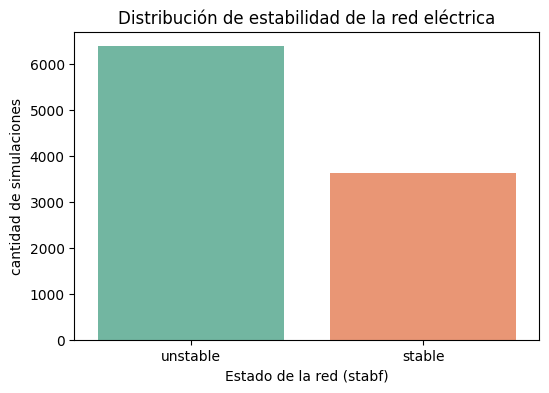

In [8]:
#Visualización
#crear lienzo en blanco para el gráfico
plt.figure(figsize=(6, 4))
#Dibujar un gráfico de barras contando los estables e intestables
sns.countplot(data=datos, x="stabf", palette="Set2")

plt.title("Distribución de estabilidad de la red eléctrica")
plt.xlabel("Estado de la red (stabf)")
plt.ylabel("cantidad de simulaciones")

plt.show()

Aquí no usare Feature selection porque todas las columnas de datos son necesarias

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Primero separo las pistas (X) de las respuestas (y)
#Quito "stabf" (la respuesta) y "stab"
X = datos.drop(columns=["stabf", "stab"])
y = datos["stabf"]

#Ahora divido 80% para estudio y 20% para prueba
#random_state=42 asegura que el corte siempre sea el mismo si vuelvo a correr el código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalar los datos (estandarización)
scaler = StandardScaler()

#El modelo "aprende" la escala con los datos de estudio y los transforma
X_train_escalado = scaler.fit_transform(X_train)

#Aplicamos la misma regla a los datos de prueba
X_test_escalado = scaler.transform(X_test)

print("Datos listos, Tenemos", X_train_escalado.shape[0],"escenarios para estudiar")
print("y", X_test_escalado.shape[0], "escenarios ocultos para el examen final")


Datos listos, Tenemos 8000 escenarios para estudiar
y 2000 escenarios ocultos para el examen final


In [ ]:
#Usando Regresión Logistica
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#Llamo al modelo
modelo_logistico = LogisticRegression()

#Lo hago estudiar los 8.000 datos
modelo_logistico.fit(X_train_escalado, y_train)

#Testeo, le pido que adivine la estabilidad de los 2.000 datos ocultos
predicciones = modelo_logistico.predict(X_test_escalado)

#Comparo sus adivinanzas con las respuestas reales
precision = accuracy_score(y_test, predicciones)
print(f"El modelo predijo la estabilidad con un {precision * 100:.2f}% de exactitud.\n")


El modelo predijo la estabilidad con un 81.60% de exactitud.



<Figure size 600x400 with 0 Axes>

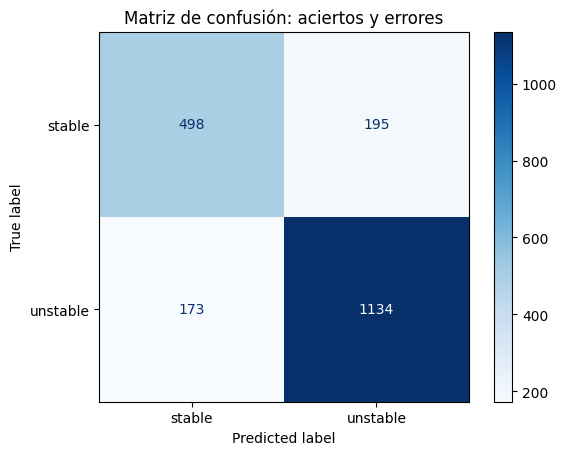

In [23]:
#Matriz de confusión con los aciertos y errores
matriz = confusion_matrix(y_test, predicciones)

grafico_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=modelo_logistico.classes_)

plt.figure(figsize=(6,4))
grafico_matriz.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión: aciertos y errores")
plt.show()

In [25]:
#Ahora usaré KNN
from sklearn.neighbors import KNeighborsClassifier

#El modelo mirará los 5 vecinos más cercanos
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_escalado, y_train)

#testeo
predicciones_knn = modelo_knn.predict(X_test_escalado)

#metricas
precision_knn = accuracy_score(y_test, predicciones_knn)

print(f"El modelo predijo la estabilidad con un {precision_knn * 100:.2f}% de exactitud.\n")

El modelo predijo la estabilidad con un 85.05% de exactitud.



<Figure size 600x400 with 0 Axes>

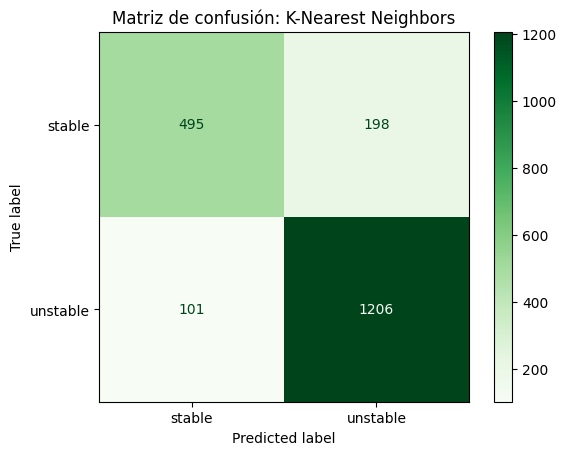

In [26]:
#matriz confusion
matriz_knn = confusion_matrix(y_test, predicciones_knn)
grafico_knn = ConfusionMatrixDisplay(confusion_matrix=matriz_knn, display_labels=modelo_knn.classes_)

plt.figure(figsize=(6, 4))
grafico_knn.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusión: K-Nearest Neighbors")
plt.show()

In [28]:
print("Comparación de modelos")
print(f"Exactitud Regresión Logística: {precision*100:.2f}%")
print(f"Exactitud K-Nearest Neighbors: {precision_knn*100:.2f}%")

Comparación de modelos
Exactitud Regresión Logística: 81.60%
Exactitud K-Nearest Neighbors: 85.05%
